# Enhanced Corporate Bond Risk Analysis Through Value Chain Inspection

## Introduction

Traditional corporate bond selection strategies frequently rely on credit ratings to assess issuer risk. While these ratings provide a useful benchmark for evaluating creditworthiness, they may not adequately capture interconnected risks arising from supply chain dependencies. This analysis proposes a more nuanced risk management approach by integrating supply chain relationships into the evaluation process for corporate bond issuers.

By analyzing shared suppliers and potential bottlenecks within the value chain, investors can identify hidden risks that credit ratings might overlook. This method allows for improved diversification and risk mitigation within corporate bond portfolios by reducing exposure to systemic supply chain disruptions that could affect multiple issuers simultaneously.

The specific process we will be implmeneting in this notebook is to identify all value chain conflicts within a defined depth (suppliers, suppliers of suppliers etc) - these conflicts are then evalauted with the following risk formula.

$$
\text{risk\_for\_conflict}(\text{conflict}) = \sum_{\text{constituent} \in \text{conflict}} \left( P_{\text{default}}(\text{constituent}) \times 10 \cdot e^{-\text{depth}_{\text{constituent}}} \right)
$$

This formula is a simplified approach, evaluating risk by using depth as a proxy for risk attenuation scaled by the probability of default for the common supply chain ancestor. It assumes that greater distance from the ancestor default allows the chain to absorb defaults (represented in the exponential decay in the e term); however, it is worth noting that it is possible that the bullwhip effect actually exacerbates the risk implications. Additionally, this formula does not consider factors such as the availability of substitute suppliers or potential response times. The decision to omit these considerations stems from their unpredictable nature, which would likely require a considerable machine learning solution to estimate reasonably.

Overall portfolio risk is evaluated as the sum of risks from all conflicts:

$$
\text{risk\_for\_portfolio}(\text{portfolio}) = \sum_{\text{conflict} \in \text{portfolio}} \text{risk\_for\_conflict}(\text{conflict})
$$

To illustrate the real world effectiveness of this approach, we will use the [SPDR](https://www.morningstar.com/etfs/arcx/spbo/portfolio) corporate bond portfolio as our diversification candidate. This portfolio has been rated 3 stars by Morningstar, indicating it is "fairly valued."

In [1]:
import lseg.data as ld
import copy
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.patches as mpatches
from lseg.data.discovery import Suppliers
from datetime import timedelta
from queue import Queue
#import matplotlib.patches as mpatches
ld.get_config()['http.request-timeout'] = 180

significant_conflict_size = 2 # Denotes minimum number of members with common ancestor deemed impermissible 
max_depth = 2 # Depth traversed in supply chain to identify number of conflicts in Portfolio

In [2]:
ld.open_session()

<lseg.data.session.Definition object at 0x133cc6cd0 {name='workspace'}>

# Simulated SPBO Corporate Bond Portfolio
This portfolio is a simulation of the [SPBO (S&P U.S. Corporate Bond Index)](https://www.morningstar.com/etfs/arcx/spbo/portfolio) to demonstrate the real-world applicability of the proposed risk mitigation tool. Here we also migrate from identifying issuers with RICs to with their Organization Permanent IDs, this ensures that the companies themselves are evaluated, rather than the specified bond holdings - and privately traded companies can still be traversed through.

In [22]:
# Generate Example Portfolio, diversified through stratified sampling from different sectors 10 of each from ['Utilities', 'Financials', 'Academic & Educational', 'Healthcare', 'Industrial', 'Real Estate', 'Energy', 'Technology', 'Institutions, Associations & Organisations' ]
for _ in range(3):
    try:
        Portfolio = ld.discovery.search(
            view = ld.discovery.Views.GOV_CORP_INSTRUMENTS,
            top = 20,
            group_by="IssuerOrgid",
            group_count=1,
            filter = "(DbType eq 'CORP' and IsActive eq true and ((IssuerOrgid eq '16597' or IssuerOrgid eq '21528' or IssuerOrgid eq '27965' or IssuerOrgid eq '106512913' or IssuerOrgid eq '28476' or IssuerOrgid eq '15445' or IssuerOrgid eq '19655' or IssuerOrgid eq '112105472' or IssuerOrgid eq '18242' or IssuerOrgid eq '31175' or IssuerOrgid eq '54198' or IssuerOrgid eq '79980' or IssuerOrgid eq '29539' or IssuerOrgid eq '135301' or IssuerOrgid eq '27965' or IssuerOrgid eq '18198' or IssuerOrgid eq '32101' or IssuerOrgid eq '28696' or IssuerOrgid eq '50364' or IssuerOrgid eq '32036')))",
            select = "RIC,DTSubjectName,SearchAllCategoryv3,SearchAllCategoryv2,SearchAllCategory,RCSTRBC2012Genealogy, DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSCouponTypeGenealogy,FaceIssuedUSD,RCSBondGradeLeaf,IssuerOrgid"
        )

    except Exception as e:
        print('Failed to pull Bonds:', e)
        print('Retrying...')
    
    
# Create lookup-table to both enforce Organization PermID referencing (over instrument), and later remapping back onto bonds in portfolio
for _ in range(3):
    try:
        portfolio_keys = ld.get_data(universe=(Portfolio['RIC'].tolist()), fields=['TR.OrganizationID']).set_index('Organization PermID')['Instrument'].to_dict()
        
        # Create alternate dictionary with key value pairs swapped
        ric_indexed_keys = {v: k for k, v in portfolio_keys.items()}
        
        # Turn the Organization IDs into list format in preparation for the supply chain traversal function
        portfolio_orgs = list(portfolio_keys.keys())
        
        # Add Organization PermID to each constituent in portfolio
        Portfolio['Organization PermID'] = Portfolio['RIC'].map(
            lambda ric: ric_indexed_keys.get(ric)
        )

    except Exception as e:
        print('Failed to pull Permanent Organisation IDs:', e)
        print('Retrying...')

### Attaching Default probabilities
As part of this process we also define a function to traverse a universe and return a dictionary of all associated default probabilities. Note that <NA> values are filled with the mean values.

In [23]:
"""
Function to query for probability of default for a list of organisations and returns a dictionary of organisations to associated default probability
"""
def find_default_probabilities(universe):
    # Add all keys to the queue
    heads_queue = Queue()
    heads_queue.put(universe)

    default_prob_dict = {}

    # Attempt to retrieve default probabilities with a queuing system
    while not heads_queue.empty():
        heads = heads_queue.get()
        step = 0

        while step < 2:
            try:
                # Call the API with the current heads
                temp_default_probabilities = ld.get_data(universe=heads, fields=['TR.CreditComboCPD'])

                # Generate average and fill <NA> values with average
                default_probability_average = temp_default_probabilities['Credit Combined PD (%)'].mean()
                temp_default_probabilities['Credit Combined PD (%)'].fillna(default_probability_average, inplace=True)

                # Update default probabilities with found values
                default_prob_dict.update(temp_default_probabilities.set_index('Instrument')['Credit Combined PD (%)'].to_dict())
                break

            except Exception as e:
                print(f"Retrieval Error: Attempts = {step + 1}\n{'Retrying...' if step < 1 else ''}")

                # Retrieval failed, split heads and add each half to the queue
                if step >= 1:
                    print(f"Failed to pull Universe: {heads}")

                    if len(heads) > 1:  # Only split if there is more than one head
                        print("Splitting heads and retrying")
                        mid_index = len(heads) // 2
                        heads_queue.put(heads[:mid_index])
                        heads_queue.put(heads[mid_index:])
                    else:
                        default_prob_dict[heads[0]] = np.mean(list(default_prob_dict.values())) # Fill with mean value 
                        print(f"Single head {heads[0]} failed after 2 attempts. Skipping...")

                    break  # Exit the retry loop after splitting
                step += 1

    return default_prob_dict


default_probabilities = find_default_probabilities(list(portfolio_keys.keys()))

Portfolio['DefaultProbability'] = Portfolio['Organization PermID'].map(
    lambda ric: default_probabilities.get(ric)
)

In [24]:
Portfolio

,RIC,DTSubjectName,SearchAllCategoryv3,SearchAllCategoryv2,SearchAllCategory,RCSTRBC2012Genealogy,DBSTicker,CouponRate,MaturityDate,IssueDate,...,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSCouponTypeGenealogy,FaceIssuedUSD,RCSBondGradeLeaf,IssuerOrgid,Organization PermID,DefaultProbability
0,CH894131=,PepsiCo Inc,Bonds,Bonds,Bonds,B:106\B:107\B:108\B:111\B:1532,PEP,1.25,NaT,1986-04-18,...,Swiss Franc,Switzerland,Corporate,Bond,M:1EU\A:1H\A:DI,447928331,Investment Grade,18242,4295904718,0.062222
1,JPM_pd.N,JPMorgan Chase & Co,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,JPM,5.75,NaT,2018-09-21,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:C1\A:25,1696250000,Investment Grade,21528,5000021791,0.114644
2,BML_pj,Bank of America Corp,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,BAC,5.52552,NaT,2005-11-17,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:1V\A:CM,600000000,Investment Grade,27965,8589934339,0.140796
3,WFC_pz,Wells Fargo & Co,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,WFC,4.75,NaT,2020-01-27,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:C1\A:25,1750000000,Investment Grade,28476,8589934175,0.174616
4,172967JM4=,Citigroup Inc,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,C,5.95,NaT,2015-04-24,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:1V\A:C9,2000000000,High Yield,29539,8589934316,0.201421
5,US211441356=,AT&T Inc,Bonds,Bonds,Bonds,B:278\B:176\B:177\B:179\B:1817,T,2.875,NaT,2020-02-18,...,Euro,Eurobond,Corporate,Preferred Security,M:1EU\A:KS\A:KT,2085810232,High Yield,31175,4295904853,0.107477
6,TD_pfd.TO,Toronto-Dominion Bank,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,TD,3.201,NaT,2015-03-10,...,Canadian Dollar,Canada,Corporate,Preferred Stock,M:1EU\A:KS\A:KT,243596881,Investment Grade,32036,4295862902,0.109360
7,38141GA38=,Goldman Sachs Group Inc,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,GS,7.5,NaT,2023-08-18,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:KS\A:KT,1500000000,High Yield,50364,4295911963,0.226007
8,MS_pq,Morgan Stanley,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,MS,6.625,NaT,2024-07-30,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:C1\A:25,1000000000,Investment Grade,54198,4295904557,0.143058
9,68269EMS8=,ONEOK Inc,Commercial Papers,Commercial Papers,Bonds,B:219\B:2\B:9\B:190\B:1024,OKE,0.0,2024-12-26,2024-12-16,...,US Dollar,United States,Corporate,Commercial Paper,M:1EU\A:C0\A:7G,<NA>,<NA>,28696,4295904660,0.262573


## Function Declarations for Value Chain Traversal
The following functions take a list of Permanent IDs for bond issuers in the original portfolio and generate a hierarchical tree of suppliers (or ancestors) within their respective value chains. The output is structured as a dictionary, where each key represents an organization ID, and its corresponding value is another dictionary containing its suppliers. This recursive structure, combined with constant-time lookup, enables efficient navigation and identification of common suppliers or value chain bottlenecks.

A queue-based approach is implemented in the API_call function to manage cases where a large universe of suppliers is requested. When an error occurs, the universe is recursively split into smaller subsets. This strategy is essential because the number of suppliers for each "head" is unknown, and the backend call could involve a significantly larger universe than initially anticipated, necessitating the breakdown of queries. A maximum retry attempt of two has been set, under the assumption that "bad" calls can occur, but they often happen consecutively due to specific problematic members of the "heads" list.

In [26]:
"""
Driver function for value chain exploration
"""
def traverse_value_chains(direction, chains, max_depth):
    chain_dict = initialize_chain_dict(chains)
    visited_dict = {}
    
    for depth in range(max_depth):

        # Retrieve Data and prune unlikely relationships
        sdf = retrieve_data(direction, chains)        
        if sdf.empty:
            print("Error Retrieving Data: Exiting")
            return chain_dict
        sdf = sdf[sdf['Value Chains Relationship Confidence Score'] > 0.5]
        
        chains = []
        # Process dataframe to update global data-structures
        sdf.apply(lambda row: process_record_deep(row, chain_dict, chains), axis=1)
        
        print(f"Finished layer {depth} Traversal")

    return chain_dict


"""
Helper functions for driver
"""
def initialize_chain_dict(chains):
    # Return appropriately structured dictionary
    return {root[-1]: {} for root in chains}
    
def process_record_deep(row, chain_dict, chains):
    row_chain = row['chain']
    newPermID = row['Related OrganizationID']
    temp_dict = chain_dict
    
    # Add new constituent to value chain dictionary
    for permID in row_chain[:-1]:
        temp_dict = temp_dict[permID]
    temp_dict[row_chain[-1]][newPermID] = {}
    
    # Add chain to chains array
    new_chain = row_chain + [newPermID]
    chains.append(new_chain)

def retrieve_data(direction, chains):
    sdf = pd.DataFrame()
    
    # Split data into chunks for separate query and concatenate results into main dataframe
    for chunk in chunks(chains, 100):
        head_and_chain = {chain[-1]: chain for chain in chunk}
        sdf = pd.concat([sdf, API_call(direction, head_and_chain)], axis=0)
    return sdf

def API_call(direction, head_and_chain):
    # Initialize queue with the initial set of heads
    head_queue = Queue()
    head_queue.put(list(head_and_chain.keys()))
    result_df = pd.DataFrame()

    while not head_queue.empty():
        heads = head_queue.get()
        print(f"Processing {len(heads)} heads...")

        value_constituents = direction(heads)
        step = 0
        while step < 2:
            try:
                # Attempt to retrieve data
                value_constituents.get_data()

                # Map chains to instruments and append the results
                value_constituents.df['chain'] = value_constituents.df['Instrument'].map(head_and_chain)
                result_df = pd.concat([result_df, value_constituents.df], ignore_index=True)
                break  # Exit the retry loop upon successful data retrieval
            except Exception as e:
                print(f"Retrieval Error: Attempts = {step + 1}\n{'Retrying...' if step < 2 else ''}")
                
                if step >= 1:
                    print(f"Failed to pull Universe: {heads}")
                    
                    # On fail, split the list into halves and add them to the queue
                    if len(heads) > 1:  # Only split if there is more than one head
                        print(f"Splitting heads and retrying")
                        mid_index = len(heads) // 2
                        head_queue.put(heads[:mid_index])  # Add the first half to the queue
                        head_queue.put(heads[mid_index:])  # Add the second half to the queue
                    else:
                        print(f"Single head {heads[0]} failed after 2 attempts. Skipping...")
                    break  # Exit the retry loop after splitting
                step += 1

    
    return result_df

# chunks function from __Examples__/09.Banking/Analysing_Value_chains.ipynb
def chunks(l, n):
    for i in range(0, len(l), n):
        yield l[i:i + n]


### Generate Data Structure for Supply Chains
Execute the previously defined function traverse_value_chains to generate the supply chain data structure.

In [27]:
portfolio_orgs_chained = [[x] for x in portfolio_orgs]
supply_chains = traverse_value_chains(Suppliers, portfolio_orgs_chained, max_depth)

Processing 19 heads...
Finished layer 0 Traversal
Processing 95 heads...
Processing 96 heads...
Processing 100 heads...
Processing 100 heads...
Processing 98 heads...
Processing 40 heads...
Finished layer 1 Traversal


## Weak Point Identification Function (Given Supply Chain Data Structure)
We define a recursive function to traverse the value chains using the provided supply chain data structure. Each unique organization is assigned a key in a lookup dictionary, termed loop_dict, where the value is a list of all bond issuers from the original portfolio that have this organization within their supply chain. This approach ensures an O(n) time complexity for traversing and analyzing the supply chain data.

In [28]:
"""
Recursive function which uses dictionary from traverse_value_chains to identify common anccestors in value chain
"""
def loop_identification(chain_dict, loop_dict=None, source='', depth=0):
    # Initialize loop_dict if it's None
    if loop_dict is None:
        loop_dict = {}
        
    # Base case
    if not chain_dict:
        return loop_dict
    
    for x in chain_dict.keys():
        # Flag to continue recursion (if location unvisited)
        traversal = True
        if depth == 0:
            source = x
            
        # Organisation already visited (from either same source or different source)
        if x in loop_dict:
            
            # Check if visited from the same source (update distance if distance from current path smaller)
            for y in loop_dict[x]:
                if y[0] == source:
                    traversal = False
                    if y[1] > depth:
                        loop_dict[x] = [(source, depth)]  # Update the entry
                        break
                    else:
                        break
                        
            # Add conflict if visited from the same source
            if (traversal):
                loop_dict[x].append((source, depth))
        
        # If unvisited, add organization to loop dictionary
        else:
            if depth != 0:
                loop_dict[x] = [(source, depth)]
        
        # Recursive case
        if traversal:
            loop_identification(chain_dict[x], loop_dict, source, depth + 1)
    
    return loop_dict

### Function: `risk_calc`

The `risk_calc` function is designed to assess the risk associated with a bond portfolio by evaluating the contribution of individual portfolio constituents to overall risk, as well as the magnitude of specific conflict scenarios. 

#### Parameters:
- **supply_chains**: A data structure representing the relationships between various entities in the supply chain, which can influence risk propagation.
- **associated_portfolio**: A Pandas DataFrame containing details about the bond portfolio, including organization identifiers and default probabilities.

#### Description:
This function performs the following key operations:

1. **Conflict Identification**: It identifies conflicts within the supply chain using the `loop_identification` function, which captures interdependencies between entities.

2. **Pruning Conflicts**: The function filters out non-relevant conflicts by retaining only those that meet a specified `significant_conflict_size`, ensuring that only meaningful conflicts are analyzed.

3. **Risk Calculation**:
   - For each identified conflict, it calculates the risk associated with each offender (i.e., portfolio constituent) by leveraging their default probability and a risk propagation model that includes an exponential decay factor based on the conflict's depth.
   - It aggregates the risks at both the individual offender level and the overall conflict level, providing a detailed score for each conflict.

4. **Outputs**: 
   - The function returns three values:
     - **total_risk**: The cumulative risk for the entire bond portfolio.
     - **individual_offender_scores**: A dictionary containing the total risk attributed to each offender in the portfolio.
     - **conflict_scores**: A list of tuples, each containing a conflict identifier and its associated risk score.

#### Purpose:
This function serves as a vital tool for risk assessment in bond portfolios, using conflict supply chain depth as a proxy for risk propagation attenuation and leveraging default probabilities to inform risk metrics. It provides insights into the relative contributions of individual portfolio constituents to overall risk, allowing for informed decision-making and risk management strategies.


In [29]:
def risk_calc(supply_chains, loop_dict, default_probs_dict):
    
    # Check if input dictionaries are None
    if supply_chains is None or loop_dict is None or default_probs_dict is None:
        raise ValueError("One or more input dictionaries are None.")
    # initialise return variables
    individual_offender_scores = {}
    total_risk = 0
    conflict_scores = []
    
    # Iterate through conflicts and update risk recordings
    for conflict, offenders in loop_dict.items():
        if conflict in default_probs_dict:
            offender_default_probability = default_probs_dict[conflict]
        else:
            offender_default_probability = None
        # Use high default probability if None found
        if offender_default_probability is None:
            offender_default_probability = 1
            
        conflict_score = 0
        
        for offender in offenders:
            # Calculate risk contribution by bond issuer
            offender_risk = offender_default_probability * 10 * np.exp(-offender[1])
            
            # Update risk recordings
            total_risk += offender_risk
            conflict_score += offender_risk
            
            if offender[0] in individual_offender_scores:
                individual_offender_scores[offender[0]] += offender_risk
            else:
                individual_offender_scores[offender[0]] = offender_risk
        
        conflict_scores.append((conflict, conflict_score))
    
    # Turn the individual scores into an array so they can be ordered by magnitude
    individual_array_scores = [(indv, score if not pd.isna(score) else 0) for indv, score in individual_offender_scores.items()]
    individual_array_scores.sort(key=lambda x: x[1])
    
    return total_risk, individual_array_scores, conflict_scores

### Generate Dictionary for Identified Weak Points and Corresponding Bonds
Execute the loop_identification function, followed by pruning the resulting dictionary to eliminate conflicts of significant magnitude.

In [30]:
loop_dict = loop_identification(supply_chains)
# Remove non-Point-of-Failure Value Chain Constituents
pruned_loop_dict = {k: v for k, v in loop_dict.items() if (lambda x: len(x) >= significant_conflict_size)(v)}

# Update global default probabilities dictionary with new conflicts
unknown_default_probs = [key for key in list(pruned_loop_dict.keys()) if key not in default_probabilities]
default_probabilities.update(find_default_probabilities(unknown_default_probs))

# Calculate risk
total_risk, individual_offender_scores, conflict_scores = risk_calc(supply_chains, pruned_loop_dict, default_probabilities)
conflict_scores.sort(key=lambda x: x[1])

## Graph Example Points of Failure from Portfolio From Each Risk Level
Using networkx and matplot we can visualise a given conflict quite easily. here we can contexualised relative constituents to risk by graphing the lowest risk collision, median risk collision and highest risk collision.

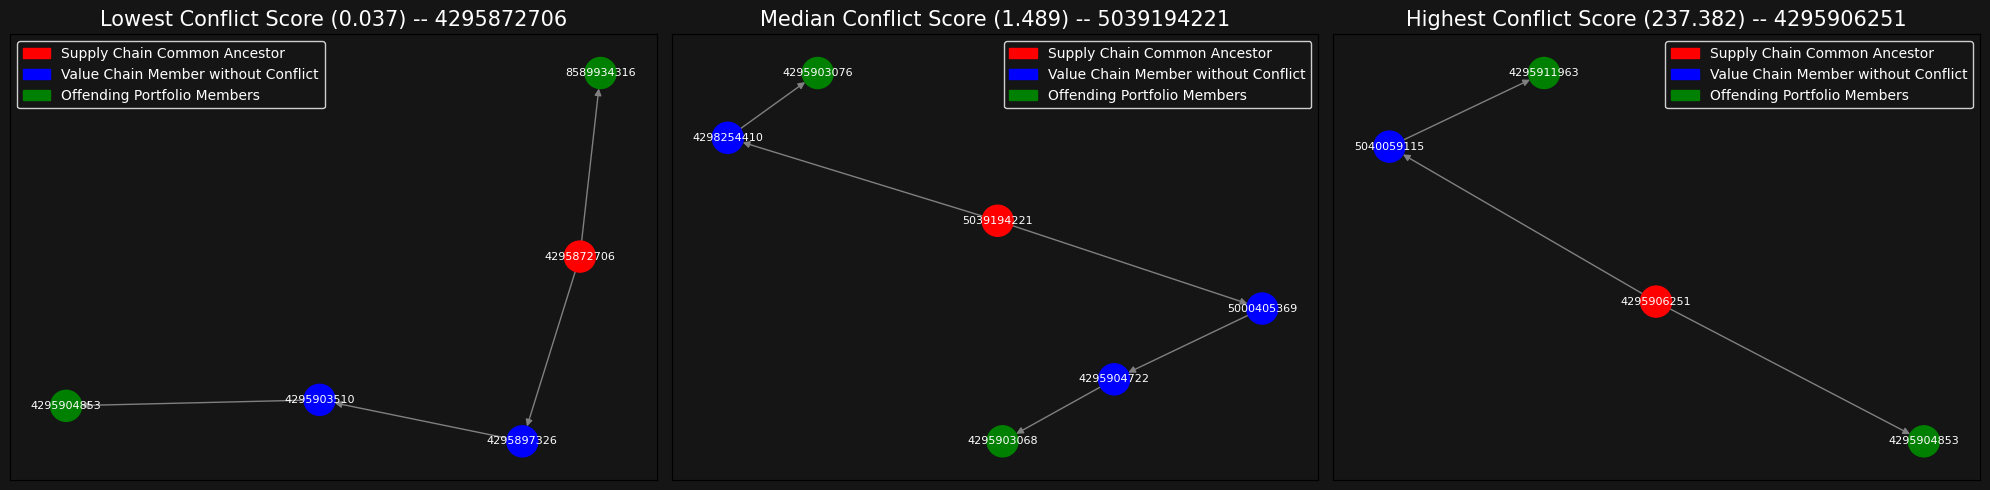

In [31]:
"""
Recursive supply chain dictionary search function to generat
"""
def construct_path(current_dict, destination, path):
    if (destination in current_dict) or (current_dict == {}):
        return path + [destination]
    else:
        for x in current_dict.keys():
            test_path = construct_path(current_dict[x], destination, path + [x])
            if test_path[-1] == destination:
                return test_path
        return path
        

def generate_conflict_graph(ax, conflict, loop_dict, risk_level):
    # Function call to idenitfy relevant conflict
    offenders = [off[0] for off in loop_dict[conflict[0]]]
    
    # Initialise variables for node and edge construction
    nodes_to_add = offenders.copy()
    edges_to_add = []

    # Identify full relevant supply chains from offending portfolio constituents to common ancestor
    for offender in offenders:
        path = construct_path(supply_chains[offender], conflict[0], [offender])
        edges_to_add += [[path[x], path[x-1]] for x in range(1, len(path))]
        nodes_to_add += [x for x in path if x not in nodes_to_add]
    
    # Setup Graph
    DG = nx.DiGraph()      
    DG.add_nodes_from(nodes_to_add)
    DG.add_edges_from(edges_to_add)
    
    # Update node colours based on supply chain status
    node_colors = [
        'red' if node == conflict[0] 
        else 'green' if node in offenders 
        else 'blue' 
        for node in DG.nodes()
    ]
    
    # Draw graph and add stylings
    nx.draw_networkx(
        DG, 
        with_labels=True, 
        node_color=node_colors, 
        edge_color='grey',
        font_color='white',
        node_size=500, 
        font_size=8, 
        ax=ax
    )

    ax.set_facecolor('#151515')
    ax.set_title(f'{risk_level} Conflict Score ({round(conflict[1], 3)}) -- {conflict[0]}', fontsize=15, color='white')

    red_patch = mpatches.Patch(color='red', label='Supply Chain Common Ancestor')
    blue_patch = mpatches.Patch(color='blue', label='Value Chain Member without Conflict')
    green_patch = mpatches.Patch(color='green', label='Offending Portfolio Members')
    ax.legend(
        handles=[red_patch, blue_patch, green_patch],
        facecolor='#151515',
        edgecolor='white',
        fontsize=10,
        labelcolor='white'
    )

    
# Generate the figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Generate and plot each graph on its respective subplot
generate_conflict_graph(axes[0], conflict_scores[0], pruned_loop_dict, "Lowest")
generate_conflict_graph(axes[1], conflict_scores[len(conflict_scores)//2], pruned_loop_dict, "Median")
generate_conflict_graph(axes[2], conflict_scores[-1], pruned_loop_dict, "Highest")
fig.patch.set_facecolor('#151515')
for ax in axes:
    ax.set_facecolor('#151515')
plt.tight_layout()
plt.show()

## Split Portfolio into Remaining Bonds and Bonds to be Reselected
Using the individual offender scores, we can identify the largest contributors to overall portfolio risk and isolate the top offenders based on a specified percentage of the total risk we aim to eliminate. It’s important to note that attempting to eliminate all risk could result in selecting very small contributors, which might inadvertently introduce additional risk into the portfolio.

In [32]:
tot = 0
index = -1
target_risk_removal = 0.8 # Change to be whatever percentage you wish
diversified_permIDs = []

while tot < total_risk * target_risk_removal:
    offender = individual_offender_scores[index]
    if offender[1] < (total_risk * 0.03):
        break
    else:
        diversified_permIDs.append(offender[0])
        tot += offender[1]
        index -= 1


        
diversified = Portfolio[Portfolio['Organization PermID'].isin(diversified_permIDs)]
remaining = Portfolio[~Portfolio['Organization PermID'].isin(diversified_permIDs)]

# Remove diversified bonds from supply chain dictionary
for org in diversified_permIDs:
    del supply_chains[org]

DataFrames of 'insecure' Bonds

In [33]:
diversified

,RIC,DTSubjectName,SearchAllCategoryv3,SearchAllCategoryv2,SearchAllCategory,RCSTRBC2012Genealogy,DBSTicker,CouponRate,MaturityDate,IssueDate,...,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSCouponTypeGenealogy,FaceIssuedUSD,RCSBondGradeLeaf,IssuerOrgid,Organization PermID,DefaultProbability
4,172967JM4=,Citigroup Inc,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,C,5.95,NaT,2015-04-24,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:1V\A:C9,2000000000,High Yield,29539,8589934316,0.201421
5,US211441356=,AT&T Inc,Bonds,Bonds,Bonds,B:278\B:176\B:177\B:179\B:1817,T,2.875,NaT,2020-02-18,...,Euro,Eurobond,Corporate,Preferred Security,M:1EU\A:KS\A:KT,2085810232,High Yield,31175,4295904853,0.107477
8,MS_pq,Morgan Stanley,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,MS,6.625,NaT,2024-07-30,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:C1\A:25,1000000000,Investment Grade,54198,4295904557,0.143058
11,097023BJ3=,Boeing Co,Bonds,Bonds,Bonds,B:234\B:235\B:36\B:37\B:1137,BA,2.5,2025-03-01,2015-02-20,...,US Dollar,United States,Corporate,Note,M:1EU\A:C1\A:25,250000000,Investment Grade,18198,4295903076,0.535169
13,37045VAG5=,General Motors Co,Bonds,Bonds,Bonds,B:255\B:70\B:71\B:72\B:1292,GM,4.0,2025-04-01,2014-11-12,...,US Dollar,United States,Corporate,Note,M:1EU\A:C1\A:25,500000000,Investment Grade,106512913,4298546138,0.138643
16,345370BN9=,Ford Motor Co,Bonds,Bonds,Bonds,B:255\B:70\B:71\B:72\B:1292,F,7.125,2025-11-15,1995-11-14,...,US Dollar,United States,Corporate,Debenture,M:1EU\A:C1\A:25,300000000,High Yield,16597,4295903068,0.338266
18,JP236476197=,Mitsubishi Corp,Bonds,Bonds,Bonds,B:234\B:239\B:47\B:48\B:1203,MITSB,1.125,2026-07-15,2021-07-15,...,US Dollar,Eurobond,Corporate,Note,M:1EU\A:C1\A:25,500000000,Investment Grade,15445,4295880570,0.064307


DataFrame of 'Secure' Bonds

In [34]:
remaining

,RIC,DTSubjectName,SearchAllCategoryv3,SearchAllCategoryv2,SearchAllCategory,RCSTRBC2012Genealogy,DBSTicker,CouponRate,MaturityDate,IssueDate,...,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSCouponTypeGenealogy,FaceIssuedUSD,RCSBondGradeLeaf,IssuerOrgid,Organization PermID,DefaultProbability
0,CH894131=,PepsiCo Inc,Bonds,Bonds,Bonds,B:106\B:107\B:108\B:111\B:1532,PEP,1.25,NaT,1986-04-18,...,Swiss Franc,Switzerland,Corporate,Bond,M:1EU\A:1H\A:DI,447928331,Investment Grade,18242,4295904718,0.062222
1,JPM_pd.N,JPMorgan Chase & Co,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,JPM,5.75,NaT,2018-09-21,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:C1\A:25,1696250000,Investment Grade,21528,5000021791,0.114644
2,BML_pj,Bank of America Corp,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,BAC,5.52552,NaT,2005-11-17,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:1V\A:CM,600000000,Investment Grade,27965,8589934339,0.140796
3,WFC_pz,Wells Fargo & Co,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,WFC,4.75,NaT,2020-01-27,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:C1\A:25,1750000000,Investment Grade,28476,8589934175,0.174616
6,TD_pfd.TO,Toronto-Dominion Bank,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,TD,3.201,NaT,2015-03-10,...,Canadian Dollar,Canada,Corporate,Preferred Stock,M:1EU\A:KS\A:KT,243596881,Investment Grade,32036,4295862902,0.109360
7,38141GA38=,Goldman Sachs Group Inc,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,GS,7.5,NaT,2023-08-18,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:KS\A:KT,1500000000,High Yield,50364,4295911963,0.226007
9,68269EMS8=,ONEOK Inc,Commercial Papers,Commercial Papers,Bonds,B:219\B:2\B:9\B:190\B:1024,OKE,0.0,2024-12-26,2024-12-16,...,US Dollar,United States,Corporate,Commercial Paper,M:1EU\A:C0\A:7G,<NA>,<NA>,28696,4295904660,0.262573
10,031162CV0=,Amgen Inc,Bonds,Bonds,Bonds,B:148\B:156\B:157\B:277\B:1729,AMGN,1.9,2025-02-21,2020-02-21,...,US Dollar,United States,Corporate,Note,M:1EU\A:C1\A:25,500000000,Investment Grade,19655,4295905537,0.169379
12,00287YCX5=RRPS,AbbVie Inc,Bonds,Bonds,Bonds,B:148\B:156\B:157\B:277\B:1729,ABBV,3.8,2025-03-15,2020-11-19,...,US Dollar,United States,Corporate,Note,M:1EU\A:C1\A:25,2889199000,Investment Grade,112105472,5037613143,0.211224
14,87264ABB0=,T-Mobile USA Inc,Bonds,Bonds,Bonds,B:278\B:176\B:177\B:179\B:1817,TMUSA,3.5,2025-04-15,2021-05-25,...,US Dollar,United States,Corporate,Note,M:1EU\A:C1\A:25,3000000000,Investment Grade,135301,4295915385,0.183487


## Query for Replacement Bond Suggestions
For each bond identified for replacement, candidate alternatives can be generated by querying the Refinitiv Data API. Filters will be applied to ensure that the replacement bonds align closely with the attributes of the original bond, including sector, coupon rate, and maturity date. This methodology establishes a targeted search space, consisting of a set of bonds, from which replacements can be selected to minimize supply chain conflicts.

In [47]:
# Domain expansion hyperparameters
coupon_allowance_range = 1
maturity_date_allowance_range = 30

"""
Row-wise function to construct query for similar bonds
"""
def construct_query(row, attempts, filters):
    coupon = row['CouponRate']
    
    # Constructing the base query
    query = (f"(DbType eq 'CORP' and IsActive eq true and InstrumentTypeDescription xeq 'Bond' "
             f"and CouponRate ge {abs(coupon - (attempts + 1) * coupon_allowance_range)} and "
             f"CouponRate le {coupon + (attempts + 1) * coupon_allowance_range}")
    
    # Adding sector filter if available
    sector = row['RCSTRBC2012Genealogy']
    if pd.notna(sector):
        sector = '(\'' + "' '".join(sector.split('\\')) + '\')'
        query += f" and RCSTRBC2012Genealogy in {sector}"
        
    # Adding maturity date filter if available
    maturity = row['MaturityDate']
    if pd.notna(maturity):
        input_date = maturity.date()
        start_date = (input_date - timedelta(days=maturity_date_allowance_range * (attempts + 1))).strftime("%Y-%m-%d")
        end_date = (input_date + timedelta(days=maturity_date_allowance_range * (attempts + 1))).strftime("%Y-%m-%d")
        query += (f" and MaturityDate ge {start_date} and MaturityDate le {end_date}")
    query += ')'
    
    # Append the constructed query to filters
    filters.append(query)

    
"""
Construction of DataFrame for Bond Diversification suggestions
"""    
def bond_replacement_generation(replacements_dataframe):
    # Skip empty dataframes
    if replacements_dataframe.empty:
        return replacements_dataframe
    
    attempts = 1
    replacement_candidates = pd.DataFrame()
    while attempts < 3:
        try:
            # Instantiate empty set of filters to query for new bond replacements
            filters = []

            # For each record (bond) to replace, generate relevant filter/query
            replacements_dataframe.apply(lambda row: construct_query(row, attempts, filters), axis=1)
            # Make API call with reference to bond it attempts to replace
            for x in range(replacements_dataframe.shape[0]):
                ndf = ld.discovery.search(view=ld.discovery.Views.GOV_CORP_INSTRUMENTS, top=30, filter=filters[x],
                                          select="RIC,DTSubjectName,SearchAllCategoryv3,SearchAllCategoryv2,SearchAllCategory,"
                                                 "DBSTicker,CouponRate,MaturityDate,IssueDate,ISIN,RCSCurrencyLeaf,RCSCountryLeaf,"
                                                 "DbTypeDescription,InstrumentTypeDescription,RCSCouponTypeGenealogy,FaceIssuedUSD,RCSBondGradeLeaf,"
                                                 "RCSTRBC2012Leaf,IndustrySubSectorDescription,RCSCouponCurrencyLeaf,RCSCurrency,RCSTRBC2012Genealogy")
                
                # If no replacement bonds, keep original
                if ndf.shape[0] == 0:
                    pd.concat([ndf, replacements_dataframe.iloc[x]])
                else:
                    ndf = ndf[~ndf['RIC'].isin(Portfolio['RIC'].tolist())]
                ndf['Replacee'] = replacements_dataframe.iloc[x]['RIC']
                replacement_candidates = pd.concat([replacement_candidates, ndf])

            # Make Replacee the first column
            columns = ['Replacee'] + [col for col in replacement_candidates.columns if col != 'Replacee']
            replacement_candidates = replacement_candidates[columns]
            break
        except ld.errors.RDError as e:
            replacement_candidates = pd.DataFrame()
            retry = "\nRetrying..." if attempts < 3 else ''
            print(f"Retrieval Error: Attempts = {attempts}{retry}")
            print(e)
            attempts += 1
    
    # Remove records with erroneous or missing data
    replacement_candidates = replacement_candidates.drop_duplicates(subset=['RIC'])
    replacement_candidates = replacement_candidates.dropna(subset=['RIC'])
    return replacement_candidates


# Generate bond replacements for each priority level
replacement_candidates = bond_replacement_generation(diversified)

### Append 'Organization PermID' Column for Portfolio Optimization Methods
By appending each organization's Permanent ID (PermID) to the corresponding record, each bond can be uniquely indexed and efficiently queried. This step ensures that portfolio optimization methods can accurately track and analyze each issuer throughout the optimization process.

In [48]:
def add_PermIDs(replacement_candidates):
    # Return nothing if empty
    if replacement_candidates.empty:
        return replacement_candidates
    
    # Query for replacementIds
    for _ in range(3):
        try:
            replacee_keys = ld.get_data(universe=(replacement_candidates['RIC'].tolist()), fields=['TR.OrganizationID']).set_index('Instrument')['Organization PermID'].to_dict()

            replacement_candidates['Organization PermID'] = replacement_candidates['RIC'].map(
                lambda ric: replacee_keys.get(ric)
            )

        except Exception as e:
            print('Failed to pull Permanent Organisation IDs:', e)
            print('Retrying...')

    return replacement_candidates

replacement_candidates = add_PermIDs(replacement_candidates)

# Filter out rows where Organization PermID is in exclusions or original portfolio
replacement_candidates = replacement_candidates[~replacement_candidates['Organization PermID'].isin(Portfolio['Organization PermID'])]

### Resultant DataFrames
'Replacee' column denotes bond in original portfolio which is suggested to change. Each record then denotes the bond recommended as the replacement.

In [49]:
replacement_candidates

,Replacee,RIC,DTSubjectName,SearchAllCategoryv3,SearchAllCategoryv2,SearchAllCategory,DBSTicker,CouponRate,IssueDate,ISIN,...,RCSCouponTypeGenealogy,FaceIssuedUSD,RCSBondGradeLeaf,RCSTRBC2012Leaf,IndustrySubSectorDescription,RCSCouponCurrencyLeaf,RCSCurrency,RCSTRBC2012Genealogy,MaturityDate,Organization PermID
0,172967JM4=,MYPZ180005=,Public Bank Bhd,Bonds,Bonds,Bonds,PUBM,5.08,2018-06-26,MYBPZ1800054,...,M:1EU\A:C1\A:25,22192632,<NA>,Banks (NEC),Banking,Malaysian Ringgit,C:K,B:261\B:262\B:127\B:128\B:1615,NaT,4295884204
1,172967JM4=,NO1110168=,Sparebanken Din Telemark,Bonds,Bonds,Bonds,SPRBTS,7.48,2021-09-28,NO0011101685,...,M:1EU\A:1V\A:C8,3989821,<NA>,Corporate Banks,Banking,Norwegian Krone,C:L,B:261\B:262\B:127\B:128\B:1616,NaT,4297443568
2,172967JM4=,OMBDBP920=OM,Bank Dhofar SAOG,Bonds,Bonds,Bonds,BKDB,7.0,2023-12-27,OM0000009205,...,M:1EU\A:C1\A:25,103898802,<NA>,Banks (NEC),Banking,Omani Rial,C:4M,B:261\B:262\B:127\B:128\B:1615,NaT,4298008653
3,172967JM4=,SE0022049995=,Landshypotek Bank AB,Bonds,Bonds,Bonds,LNDHYN,5.416,2024-05-15,SE0022049995,...,M:1EU\A:1V\A:C8,45404600,<NA>,Corporate Banks,Financial - Other,Swedish Krona,C:T,B:261\B:262\B:127\B:128\B:1616,NaT,4296266752
4,172967JM4=,KR6316141C7=,Woori Financial Group Inc,Bonds,Bonds,Bonds,WRFGR,4.99,2022-07-28,KR6316141C76,...,M:1EU\A:KS\A:KT,207674256,<NA>,Banks (NEC),Banking,South Korean Won,C:H,B:261\B:262\B:127\B:128\B:1615,NaT,5067500816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25,JP236476197=,CN255193SH=,Huangshi City Development Investment Group Co Ltd,Bonds,Bonds,Bonds,HSDIG,2.33,2024-07-01,<NA>,...,M:1EU\A:C1\A:25,53453214,<NA>,"Passenger Transportation, Ground & Sea (NEC)",Financial - Other,Chinese Yuan,C:2,B:234\B:56\B:248\B:66\B:1271,2026-07-01,5071078726
26,JP236476197=,KR604705397=,Posco International Corp,Bonds,Bonds,Bonds,DWINT,1.954,2019-07-04,KR6047053972,...,M:1EU\A:C1\A:25,34612376,<NA>,Diversified Industrial Goods Wholesale,Service - Other,South Korean Won,C:H,B:234\B:239\B:47\B:48\B:1203,2026-07-04,4295882337
27,JP236476197=,CA83367LDZ63=CDLR,Societe de Transport de Levis,Bonds,Bonds,Bonds,SOCTR,1.35,2021-07-05,CA83367LDZ63,...,M:1EU\A:C1\A:25,<NA>,<NA>,Charter Bus Services,Transportation - Other,Canadian Dollar,C:1,B:234\B:56\B:248\B:66\B:1273,2026-07-05,5000679385
28,JP236476197=,KR6012632B7=,HDC Holdings Co Ltd,Bonds,Bonds,Bonds,HYDEC,2.915,2021-07-05,KR6012632B78,...,M:1EU\A:C1\A:25,13844950,<NA>,Construction & Engineering (NEC),Service - Other,South Korean Won,C:H,B:234\B:239\B:240\B:241\B:1189,2026-07-05,4295881646


## Traversing Replacement Candidates' Supply Chains
To optimize the selection of replacement bonds, it is essential to evaluate their supply chains in the same manner as the original bonds. The following code block performs this by traversing the suppliers of each candidate bond to generate its supply chain structure. This process ensures that the chosen replacement bonds will minimize conflicts with the existing portfolio.

In [50]:
replacement_orgs_chained = [[org] for org in replacement_candidates['Organization PermID'].tolist()]

replacement_supply_chains = traverse_value_chains(Suppliers, replacement_orgs_chained, max_depth)

Processing 84 heads...
Processing 78 heads...
Finished layer 0 Traversal
Processing 61 heads...
Finished layer 1 Traversal


## Create Dictionary of Replacement Bonds Grouped by 'Replacee' RIC
To facilitate efficient conflict testing and portfolio optimization, the replacement bonds are organized into a dictionary based on the 'replacee' RIC (Reference Identification Code) of the original bonds. This approach enables easy management and analysis of replacement options for each bond in the original portfolio.

In [51]:
def form_dict(row, temp_dict):
    temp_dict[row['Organization PermID']] = copy.deepcopy(replacement_supply_chains[row['Organization PermID']])
    
def instantiate_candidate_dicts(replacement_candidates):
    if replacement_candidates.empty:
        return {}
    candidate_dicts = {}
    for replacee in replacement_candidates['Replacee'].unique():
        temp_dict = {}
        subset_df = replacement_candidates[replacement_candidates['Replacee'] == replacee]
        subset_df.apply(lambda row: form_dict(row, temp_dict), axis=1)
        candidate_dicts[replacee] = temp_dict
    return candidate_dicts

candidate_dicts = instantiate_candidate_dicts(replacement_candidates)

### Greedy Portfolio Optimisation Function Definitions

Here I provide a Greedy Portfolio Optimisation method. Individual solutions for different common ancestor depth categories are generated in decreasing order of risk (and therefore priority) - thereby ensuring that higher priority risks are resolved first. A greedy algorithm performs admirably in this context due to the limited scope of the search space (shallow supplier traversal depth). You could explore alternative optimisation methods - however, after trialling a genetic generation method, generated solutions severely underperformed in both generation time and risk reduction performance.

In [52]:
def fitness(sub_dict, supply_chains, default_probabilities):
    
    # Combine the original supply chains with the current subset
    trial_dict = {**supply_chains, **sub_dict}
    
    # Find conflict present in specific replacement trial
    trial_loop_dict = loop_identification(trial_dict)
    trial_pruned_loop_dict = {k: v for k, v in trial_loop_dict.items() if len(v) >= significant_conflict_size}
    
    # Evaluate performance with risk_calc function
    total_risk, individual_offender_scores, conflict_scores = risk_calc(trial_dict, trial_pruned_loop_dict, default_probabilities)        
    
    return total_risk


def greedy_generation(candidate_dicts, supply_chains, order, default_probabilities):
    choices = []
    
    for ric in order:
        sub_dict = candidate_dicts[ric]
        
        # make new supply chains dict with all replacement candidate orgs so all possible conflict default probabilities can be found in one batch call
        default_prob_dict = copy.deepcopy(supply_chains)
        for org in sub_dict.keys():
            default_prob_dict[org] = sub_dict[org]
        
        # Identify loops and prune based on conflict size
        loop_dict = loop_identification(default_prob_dict)
        trial_pruned_loop_dict = {k: v for k, v in loop_dict.items() if len(v) >= significant_conflict_size}
        
        # Update global default probabilities for conflicts with unknown default probability
        unknown_default_probs = [key for key in list(trial_pruned_loop_dict.keys()) if key not in default_probabilities]
        if len(unknown_default_probs) != 0:
            default_probabilities.update(find_default_probabilities(unknown_default_probs))
        
        # Find the organization with the minimum risk score
        min_org = min(sub_dict.keys(), key=lambda org: fitness({org: sub_dict[org]}, supply_chains, default_probabilities))
        
        # Select the organization with the highest fitness (minimum risk) and fold into dictionary for next iteration
        choices.append(min_org)
        supply_chains[min_org] = sub_dict[min_org]

    return choices

### Generate the solution

In [53]:
# Generate solution in order of highest offending portfolio constituent
order = [portfolio_keys[val] for val in diversified_permIDs]
best_solution = greedy_generation(candidate_dicts, supply_chains, order, default_probabilities)

### Generate New Portfolio
Once the solution is generated using either the Greedy or Genetic Algorithm, it is used to update the portfolio. The generated replacement bonds are mapped to the previously created 'diversified' DataFrame, which uses the Perm OrganizationID as the index. This approach ensures that the replacement bonds are efficiently integrated into the new portfolio without the need to re-query the API.

In [54]:
replacements = replacement_candidates[replacement_candidates['Organization PermID'].isin(best_solution)]
nPortfolio = pd.concat([remaining, replacements])

In [55]:
nPortfolio

,RIC,DTSubjectName,SearchAllCategoryv3,SearchAllCategoryv2,SearchAllCategory,RCSTRBC2012Genealogy,DBSTicker,CouponRate,MaturityDate,IssueDate,...,FaceIssuedUSD,RCSBondGradeLeaf,IssuerOrgid,Organization PermID,DefaultProbability,Replacee,RCSTRBC2012Leaf,IndustrySubSectorDescription,RCSCouponCurrencyLeaf,RCSCurrency
0,CH894131=,PepsiCo Inc,Bonds,Bonds,Bonds,B:106\B:107\B:108\B:111\B:1532,PEP,1.25,NaT,1986-04-18,...,447928331,Investment Grade,18242,4295904718,0.062222,NaN,<NA>,<NA>,<NA>,<NA>
1,JPM_pd.N,JPMorgan Chase & Co,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,JPM,5.75,NaT,2018-09-21,...,1696250000,Investment Grade,21528,5000021791,0.114644,NaN,<NA>,<NA>,<NA>,<NA>
2,BML_pj,Bank of America Corp,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,BAC,5.52552,NaT,2005-11-17,...,600000000,Investment Grade,27965,8589934339,0.140796,NaN,<NA>,<NA>,<NA>,<NA>
3,WFC_pz,Wells Fargo & Co,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,WFC,4.75,NaT,2020-01-27,...,1750000000,Investment Grade,28476,8589934175,0.174616,NaN,<NA>,<NA>,<NA>,<NA>
6,TD_pfd.TO,Toronto-Dominion Bank,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,TD,3.201,NaT,2015-03-10,...,243596881,Investment Grade,32036,4295862902,0.109360,NaN,<NA>,<NA>,<NA>,<NA>
7,38141GA38=,Goldman Sachs Group Inc,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,GS,7.5,NaT,2023-08-18,...,1500000000,High Yield,50364,4295911963,0.226007,NaN,<NA>,<NA>,<NA>,<NA>
9,68269EMS8=,ONEOK Inc,Commercial Papers,Commercial Papers,Bonds,B:219\B:2\B:9\B:190\B:1024,OKE,0.0,2024-12-26,2024-12-16,...,<NA>,<NA>,28696,4295904660,0.262573,NaN,<NA>,<NA>,<NA>,<NA>
10,031162CV0=,Amgen Inc,Bonds,Bonds,Bonds,B:148\B:156\B:157\B:277\B:1729,AMGN,1.9,2025-02-21,2020-02-21,...,500000000,Investment Grade,19655,4295905537,0.169379,NaN,<NA>,<NA>,<NA>,<NA>
12,00287YCX5=RRPS,AbbVie Inc,Bonds,Bonds,Bonds,B:148\B:156\B:157\B:277\B:1729,ABBV,3.8,2025-03-15,2020-11-19,...,2889199000,Investment Grade,112105472,5037613143,0.211224,NaN,<NA>,<NA>,<NA>,<NA>
14,87264ABB0=,T-Mobile USA Inc,Bonds,Bonds,Bonds,B:278\B:176\B:177\B:179\B:1817,TMUSA,3.5,2025-04-15,2021-05-25,...,3000000000,Investment Grade,135301,4295915385,0.183487,NaN,<NA>,<NA>,<NA>,<NA>


In [44]:
Portfolio

,RIC,DTSubjectName,SearchAllCategoryv3,SearchAllCategoryv2,SearchAllCategory,RCSTRBC2012Genealogy,DBSTicker,CouponRate,MaturityDate,IssueDate,...,RCSCurrencyLeaf,RCSCountryLeaf,DbTypeDescription,InstrumentTypeDescription,RCSCouponTypeGenealogy,FaceIssuedUSD,RCSBondGradeLeaf,IssuerOrgid,Organization PermID,DefaultProbability
0,CH894131=,PepsiCo Inc,Bonds,Bonds,Bonds,B:106\B:107\B:108\B:111\B:1532,PEP,1.25,NaT,1986-04-18,...,Swiss Franc,Switzerland,Corporate,Bond,M:1EU\A:1H\A:DI,447928331,Investment Grade,18242,4295904718,0.062222
1,JPM_pd.N,JPMorgan Chase & Co,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,JPM,5.75,NaT,2018-09-21,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:C1\A:25,1696250000,Investment Grade,21528,5000021791,0.114644
2,BML_pj,Bank of America Corp,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,BAC,5.52552,NaT,2005-11-17,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:1V\A:CM,600000000,Investment Grade,27965,8589934339,0.140796
3,WFC_pz,Wells Fargo & Co,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,WFC,4.75,NaT,2020-01-27,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:C1\A:25,1750000000,Investment Grade,28476,8589934175,0.174616
4,172967JM4=,Citigroup Inc,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,C,5.95,NaT,2015-04-24,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:1V\A:C9,2000000000,High Yield,29539,8589934316,0.201421
5,US211441356=,AT&T Inc,Bonds,Bonds,Bonds,B:278\B:176\B:177\B:179\B:1817,T,2.875,NaT,2020-02-18,...,Euro,Eurobond,Corporate,Preferred Security,M:1EU\A:KS\A:KT,2085810232,High Yield,31175,4295904853,0.107477
6,TD_pfd.TO,Toronto-Dominion Bank,Bonds,Bonds,Bonds,B:261\B:262\B:127\B:128\B:1615,TD,3.201,NaT,2015-03-10,...,Canadian Dollar,Canada,Corporate,Preferred Stock,M:1EU\A:KS\A:KT,243596881,Investment Grade,32036,4295862902,0.109360
7,38141GA38=,Goldman Sachs Group Inc,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,GS,7.5,NaT,2023-08-18,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:KS\A:KT,1500000000,High Yield,50364,4295911963,0.226007
8,MS_pq,Morgan Stanley,Bonds,Bonds,Bonds,B:261\B:262\B:263\B:207\B:1633,MS,6.625,NaT,2024-07-30,...,US Dollar,United States,Corporate,Depositary Share of Preferred Stock,M:1EU\A:C1\A:25,1000000000,Investment Grade,54198,4295904557,0.143058
9,68269EMS8=,ONEOK Inc,Commercial Papers,Commercial Papers,Bonds,B:219\B:2\B:9\B:190\B:1024,OKE,0.0,2024-12-26,2024-12-16,...,US Dollar,United States,Corporate,Commercial Paper,M:1EU\A:C0\A:7G,<NA>,<NA>,28696,4295904660,0.262573


## Test Conflicts
Here we evaluate our diversified portfolio and compare to the original portfolio.

In [45]:
# Generate evaluation metrics for new portfolio
new_loop_dict = loop_identification(supply_chains)
# Remove non-Point-of-Failure Value Chain Constituents
new_pruned_loop_dict = {k: v for k, v in new_loop_dict.items() if (lambda x: len(x) >= significant_conflict_size)(v)}

# Update global default probabilities with found conflicts
unknown_default_probs = [key for key in list(new_pruned_loop_dict.keys()) if key not in default_probabilities]
if len(unknown_default_probs) != 0:
    default_probabilities.update(find_default_probabilities(unknown_default_probs))

# Calculate risk
new_total_risk, new_individual_offender_scores, new_conflict_scores = risk_calc(supply_chains, new_pruned_loop_dict, default_probabilities)

print(f"Old Portfolio Risk {total_risk}")
print(f"New Portfolio Risk: {new_total_risk}")

Old Portfolio Risk 1358.4198665529318
New Portfolio Risk: 41.82480772740843
